<a href="https://colab.research.google.com/github/Neel58/EigenForge--Dimensionality-Reduction-Representation-Learning/blob/main/EigenForge_%E2%80%94_Dimensionality_Reduction_%26_Representation_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EigenForge — Advanced Dimensionality Reduction & Representation Learning


<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/02_end_to_end_machine_learning_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/02_end_to_end_machine_learning_project.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>



This notebook provides a comprehensive exploration of dimensionality reduction methods, including:

- **Manual PCA via SVD**: Understanding Principal Component Analysis through Singular Value Decomposition
- **Sklearn PCA Variants**: Standard PCA, Incremental PCA, and Randomized PCA
- **Johnson-Lindenstrauss Random Projections**: Distance-preserving random projection methods
- **Manifold Learning Methods**: t-SNE, MDS, and Locally Linear Embedding (LLE)

All techniques are demonstrated and compared using:
- **Möbius Strip Dataset**: A 3D synthetic manifold for visualization and intuition
- **MNIST Dataset**: A 784-dimensional real-world dataset for practical performance evaluation

This notebook explores trade-offs between computational efficiency, data preservation, and practical accuracy.

In [36]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.random_projection import johnson_lindenstrauss_min_dim, GaussianRandomProjection, SparseRandomProjection
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import  SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.manifold import TSNE,MDS, LocallyLinearEmbedding
from tensorflow.keras.datasets import mnist # Added for MNIST data loading

In [37]:


# --- 1. GENERATE THE DATASET ---

n_points = 5000
R = 3.5  # Main radius of the loop
w = 0.7  # Width of the strip

# Randomly sample 'u' (angle around the loop) and 'v' (position across the width)
u = np.random.uniform(0, 2 * np.pi, n_points)
v = np.random.uniform(-w, w, n_points)

# Parametric equations for the Möbius Strip
x = (R + v * np.cos(u / 2)) * np.cos(u)
y = (R + v * np.cos(u / 2)) * np.sin(u)
z = v * np.sin(u / 2)

# Optional: Add a tiny bit of Gaussian noise to make it look like real-world data
noise_level = 0.02
x += np.random.normal(0, noise_level, n_points)
y += np.random.normal(0, noise_level, n_points)
z += np.random.normal(0, noise_level, n_points)

# Store in a DataFrame
df = pd.DataFrame({
    'X': x,
    'Y': y,
    'Z': z,
    'Angle (u)': u  # We will use this to color-code the strip
})

# --- 2. VISUALIZE IN 3D ---

# Create an interactive 3D scatter plot
fig = px.scatter_3d(
    df,
    x='X',
    y='Y',
    z='Z',
    color='Angle (u)',          # Colors points based on where they are in the loop
    color_continuous_scale='bluered', # 'turbo' or 'viridis' look great for gradients
    opacity=0.8,
    title='Interactive 3D Möbius Strip Dataset'
)

# Tweak the marker size so it looks like a clean surface rather than giant blobs
fig.update_traces(marker=dict(size=3))

# Launch the visualization
fig.show()

### Manual PCA via SVD

Principal Component Analysis (PCA) can be computed directly using Singular Value Decomposition (SVD). This approach shows the mathematical foundation of PCA:
- Center the data
- Compute SVD of the centered data matrix
- Use the right-singular vectors as principal components
- Project data onto the principal components to reduce dimensions

## Part 1: Möbius Strip Visualization

We start with a synthetic Möbius Strip dataset to visualize and understand dimensionality reduction in action. The Möbius Strip is a classic non-orientable 2D manifold embedded in 3D space—perfect for demonstrating how DR methods capture underlying structure.

In [38]:
X = df[['X', 'Y', 'Z']].values
X_centered = X-X.mean(axis=0)
U,s, vt = np.linalg.svd(X_centered)
c1 = vt[0]
c2 = vt[1]

In [39]:
W2 = vt[:2].T
X_2D =  X_centered @ W2
X_2D.shape

(5000, 2)

## Part 2: Standard PCA with Scikit-Learn

Scikit-Learn's PCA implementation provides an efficient, optimized approach to dimensionality reduction. It automatically handles centering, standardization, and component extraction, making it the practical choice for most applications.

In [40]:
pca =  PCA(n_components=2)
X_2D  = pca.fit_transform(X)
X_2D.shape


(5000, 2)

### Explained Variance Ratio

The `explained_variance_ratio_` attribute shows what fraction of the dataset's variance is captured by each principal component:

- **explained_variance_ratio_[0]**: Proportion of total variance explained by the 1st PC
- **explained_variance_ratio_[1]**: Proportion of total variance explained by the 2nd PC
- etc.

**Key Insight**: By summing these ratios, we can determine how many components are needed to preserve, say, 95% of the original data's variance. This helps us decide the optimal reduced dimensionality.




In [41]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_)

[0.50223314 0.49123172]
[6.219398   6.08316198]


Now lets look on the mnist data since it has 784 dimensions

In [42]:
from sklearn.decomposition import PCA
import numpy as np

# Load data using TensorFlow Keras datasets
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Reshape and normalize image data
X_train = X_train.reshape(-1, 28 * 28).astype(np.float32) / 255.0
X_test = X_test.reshape(-1, 28 * 28).astype(np.float32) / 255.0

pca = PCA()
pca.fit(X_train)

cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1
print(d)

154


In [43]:
pca = PCA(n_components=0.95)
X_RED = pca.fit_transform(X_train)
X_RED.shape

(60000, 154)

In [44]:
clf = Pipeline([
    ('pca',PCA(random_state=42)),
    ('rnd_for',RandomForestClassifier(random_state=42))
])
param_dist = {
    "pca__n_components" : np.arange(10,80),
    "rnd_for__n_estimators" : np.arange(50, 500)
}
rnd_search = RandomizedSearchCV(clf, param_distributions=param_dist, n_iter=10, cv=3,random_state=42)
rnd_search.fit(X_train[:1000], y_train[:1000])
print(rnd_search.best_params_)

{'rnd_for__n_estimators': np.int64(475), 'pca__n_components': np.int64(57)}


In [45]:
model = rnd_search.best_estimator_
print(model.named_steps['pca'].n_components)

57


## Part 4: Randomized PCA

Randomized PCA is a faster approximate algorithm useful when we only need the first few components. Instead of computing the full SVD, it uses randomized linear algebra to find the k largest principal components with high accuracy.

**Advantages**:
- Significantly faster than standard PCA for high-dimensional data
- Requires computing far fewer singular vectors
- Results are nearly identical to standard PCA for well-separated eigenvalues

**Trade-off**: Accuracy decreases slightly for very small datasets or when many components are needed.

In [46]:
X_recovered = pca.inverse_transform(X_RED)

In [47]:
def plot_image(data):
  image = data.reshape(28,28)
  plt.figure(figsize=(3, 3))
  plt.imshow(image, cmap = 'cool')
  plt.axis("off")
  plt.show()

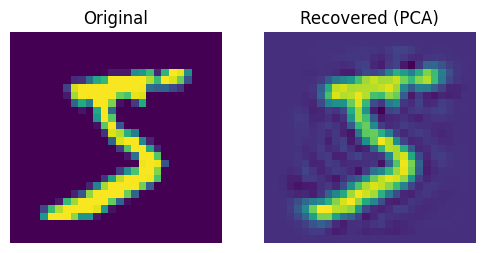

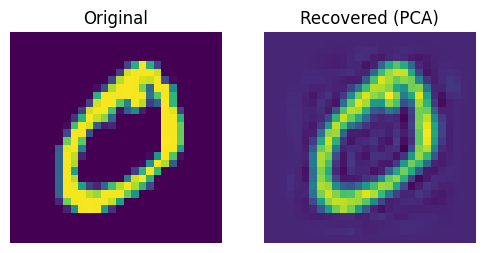

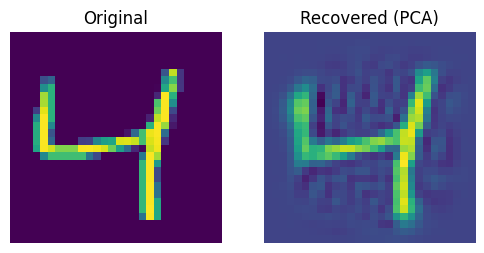

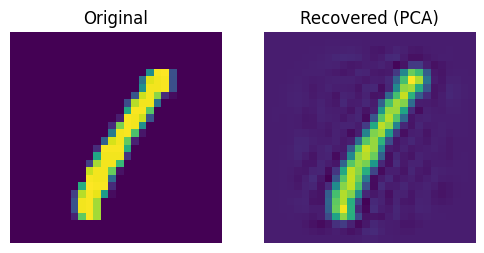

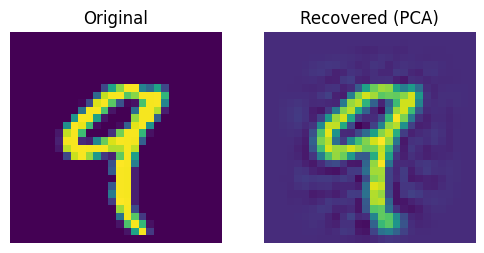

In [48]:
import matplotlib.pyplot as plt

def plot_comparison(original, recovered):
    # Create a figure with 1 row and 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))

    # Plot Original on the left
    axes[0].imshow(original.reshape(28, 28), cmap='viridis')
    axes[0].set_title("Original")
    axes[0].axis("off")

    # Plot Recovered on the right
    axes[1].imshow(recovered.reshape(28, 28), cmap='viridis')
    axes[1].set_title("Recovered (PCA)")
    axes[1].axis("off")

    plt.show()

# Loop through and plot them side-by-side!
for X_ORIG, X_RECOV in zip(X_train[:5], X_recovered[:5]):
    plot_comparison(X_ORIG, X_RECOV)

# X_recovered = X_d_projcn * W_d.T



(normal pca , randomized pca)


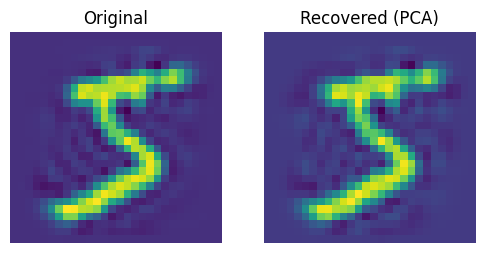

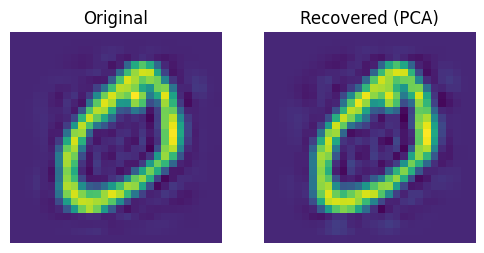

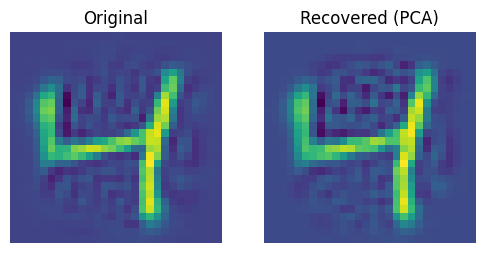

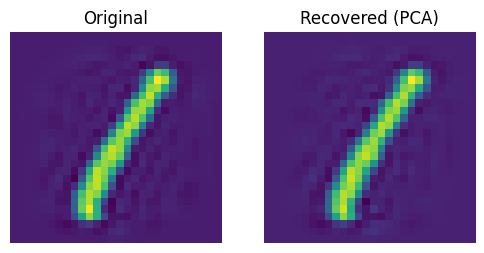

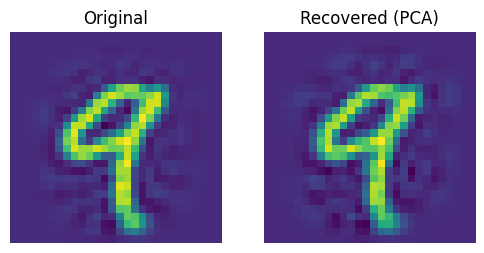

In [49]:
rnd_pca = PCA(n_components = 154 , svd_solver= 'randomized',iterated_power=6, random_state=42)
X_RED = rnd_pca.fit_transform(X_train)
X_RED.shape
X_REC = pca.inverse_transform(X_RED)
print( "(normal pca , randomized pca)")
for X_ORIG, X_RECOV in zip(X_recovered[:5], X_REC[:5]):
    plot_comparison(X_ORIG, X_RECOV)

## Part 3: Incremental PCA

Incremental PCA is designed for large datasets that don't fit in memory. Instead of computing SVD on the entire dataset at once, it processes data in mini-batches using `partial_fit()`. This approach is memory-efficient and allows fitting on streaming data or disk-based datasets.

**Use Case**: When data is too large for standard PCA but dimensionality reduction is still needed.

In [50]:
n_batches =100
inc_pca = IncrementalPCA(n_components=154)
for X_batch in np.array_split(X_train, n_batches):
  inc_pca.partial_fit(X_batch)
X_RED = inc_pca.transform(X_train)

**OR**

In [51]:
file_name = "my_mnist.mmap"
X_mmap = np.memmap(file_name, dtype= 'float32', mode = 'write', shape = X_train.shape)

X_mmap[:] = X_train
X_mmap.flush()

In [52]:
X_mmap =  np.memmap(file_name, dtype='float32', mode='readonly').reshape(-1,784)
batch_size = X_mmap.shape[0]
print(X_mmap.shape[0])
inc_pca = IncrementalPCA(n_components=154, batch_size=batch_size)
inc_pca.fit(X_mmap)

60000


IncrementalPCA(batch_size=60000, n_components=154)

In [53]:
X_RED_INC = inc_pca.transform(X_train)
X_REC_INC = inc_pca.inverse_transform(X_RED_INC)


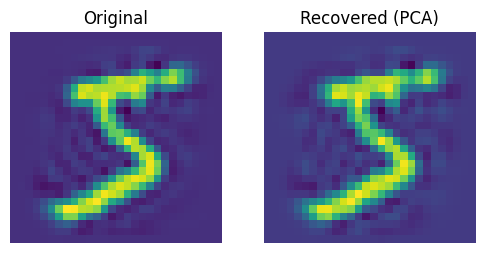

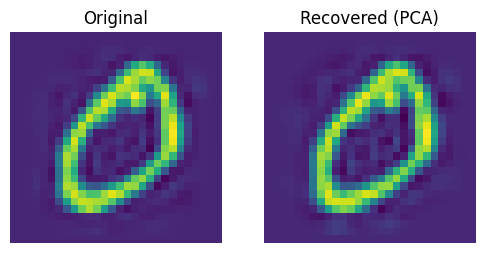

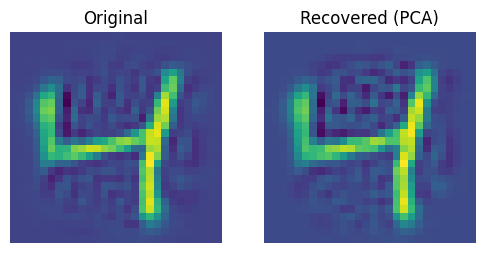

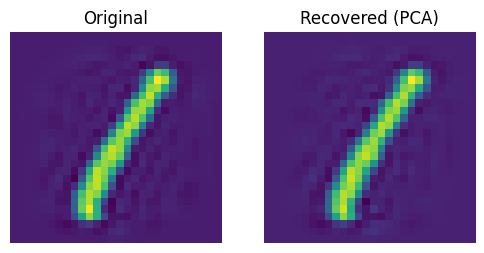

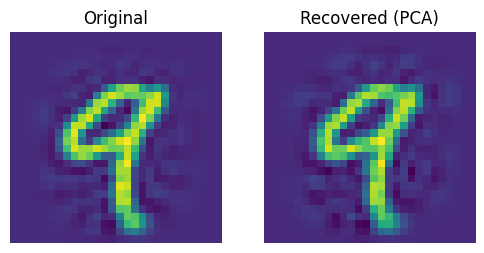

In [54]:
for X_ORIG, X_RECOV in zip(X_REC_INC[:5], X_REC[:5]):
    plot_comparison(X_ORIG, X_RECOV)

> COMPUTATIONNAL TIME COMPLEXITY OF PCA - **O(m *d²) + O(d³)***





## Part 5: Johnson-Lindenstrauss Random Projections

Random projections are a fundamentally different approach to dimensionality reduction. Instead of finding optimal directions like PCA, they use random matrices to project data into lower dimensions while approximately preserving pairwise distances.

**Key Advantage**:
- Computationally very cheap (just random matrix multiplication)
- Provably preserves distances up to a user-specified tolerance ε (epsilon)
- Works well when the number of features is very large compared to samples

**Distance Preservation Formula**:
The Johnson-Lindenstrauss Lemma guarantees that if we reduce to dimension $d$, where:
$$d \geq \frac{4\log(m)}{\frac{\varepsilon^2}{2} - \frac{\varepsilon^3}{3}}$$
then distances are preserved within factor $(1 ± \varepsilon)$, where $m$ is the number of samples.

> ***`d >= 4log(m) / (1/2 e² + 1/3 e³ )`***

*e = epsilon  i.e. tolerance*

In [55]:
m = X_train.shape[0]
e = 0.1
d= johnson_lindenstrauss_min_dim(m, eps=e)
print(" the reduced dimensions are : ", d)
print("original features = 0",X_train.shape[1])

m , e = 5000,0.1
n=20000
d=johnson_lindenstrauss_min_dim(m, eps=e)
np.random.seed(42)
P = np.random.randn(d,n) /np.sqrt(d)   # std dev = sqrt of variance
X = np.random.randn(m,n) # Fake dataset
X_RED = X @ P.T


 the reduced dimensions are :  9430
original features = 0 784


In [56]:
print(X_RED.shape)

(5000, 7300)


### Johnson–Lindenstrauss Conclusion

- The required reduced dimension \( d \) depends on **number of samples (m)**, not original features.
- Formula intuition: \( d \propto \frac{\log(m)}{\varepsilon^2} \)

#### Observations
- **5000 samples, 20,000 features → d < original features**  
  ✔ Effective dimensionality reduction

- **600,000 samples, 784 features → d ≈ 9000 > original features**  
  ❌ Not a reduction (dimension increases)

#### Final Takeaway
- Johnson–Lindenstrauss is a **distance-preserving guarantee**, not always a reduction method.
- Works well when:
  - Features ≫ samples  
- Fails when:
  - Samples ≫ features

#### Practical Rule
> Use JL only when it actually reduces dimensions; otherwise prefer PCA or other methods.

-------------------------------------------------------------------------------------------------------------------------------------------
> gaussian and sparse Random projection functions 🏹
-------------------------------------------------------------------------------------------------------------------------------------------

In [57]:
import time
start = time.perf_counter()

gaussian_rnd_proj = GaussianRandomProjection(eps=e, random_state=344)
X_RED = gaussian_rnd_proj.fit_transform(X)

end = time.perf_counter()
print("Time taken:", end - start, "seconds")

Time taken: 59.085919187999025 seconds


In [58]:
print("using gaussian random projection :",X_RED.shape)

using gaussian random projection : (5000, 7300)


In [59]:
import time
start = time.perf_counter()

sparse_proj = SparseRandomProjection(eps=e, random_state=334)
X_RED  = sparse_proj.fit_transform(X)
print("using sparse  random projection :",X_RED.shape)

end = time.perf_counter()
print("Time taken:", end - start, "seconds")

using sparse  random projection : (5000, 7300)
Time taken: 12.503032274000361 seconds


In [60]:
X_train.shape

(60000, 784)





# EXPERIMENT 1

In [61]:
# Concatenate X_train and X_test to form the full dataset X
X = np.concatenate((X_train, X_test), axis=0)
# Concatenate y_train and y_test to form the full labels y
y = np.concatenate((y_train, y_test), axis=0)

In [62]:
start = time.perf_counter()
rnd_clf = RandomForestClassifier(random_state=42)
rnd_clf.fit(X_train, y_train)
pred = rnd_clf.predict(X_test)
accuracy_score(y_test,pred)
end = time.perf_counter()
print("Time taken without dimensionality reduction : " , end - start, "seconds")
print("accuracy  without dimensionality reduction", accuracy_score(y_test,pred))

Time taken without dimensionality reduction :  55.59485854399827 seconds
accuracy  without dimensionality reduction 0.9704


Time taken with dimensionality reduction using pipeline of pca and rnd_clf :  195.296245732 seconds

accuracy  with dimensionality reduction 0.9488

In [63]:

# pca = PCA(n_components=0.95,random_state=42)
rnd_clf = RandomForestClassifier(random_state=42)
sparse_proj = SparseRandomProjection(eps=0.4, random_state=42)

# Fit on ALL data (70,000) X, THEN split using original train/test lengths
X_red_all = sparse_proj.fit_transform(X) # Use the concatenated X
X_train_red, X_test_red = X_red_all[:len(X_train)], X_red_all[len(X_train):]

start = time.perf_counter()
rnd_clf.fit(X_train_red, y_train)
pred = rnd_clf.predict(X_test_red)
accuracy_score(y_test, pred)
end = time.perf_counter()
print("Time taken with dimensionality reduction : " , end - start, "seconds")
print("accuracy  with dimensionality reduction", accuracy_score(y_test,pred))

Time taken with dimensionality reduction :  360.03688470999987 seconds
accuracy  with dimensionality reduction 0.9505


> **lets try with SGDClassifier**

In [64]:
start = time.perf_counter()
rnd_clf = SGDClassifier(random_state=42)
rnd_clf.fit(X_train, y_train)
pred = rnd_clf.predict(X_test)
accuracy_score(y_test,pred)
end = time.perf_counter()
print("Time taken without dimensionality reduction with sgd : " , end - start, "seconds")
print("accuracy  without dimensionality reduction", accuracy_score(y_test,pred))

Time taken without dimensionality reduction with sgd :  24.70393120600056 seconds
accuracy  without dimensionality reduction 0.9191


In [65]:

pca = PCA(n_components=0.95,random_state=42)
sgd_clf = SGDClassifier(random_state=42)
X_red = pca.fit_transform(X)
X_train_red , X_test_red= X_red[:60000], X_red[60000:]

start = time.perf_counter()
sgd_clf.fit(X_train_red,y_train)
pred = sgd_clf.predict(X_test_red)
accuracy_score(y_test, pred)
end = time.perf_counter()
print("Time taken with dimensionality reduction by sgd: " , end - start, "seconds")
print("accuracy  with dimensionality reduction", accuracy_score(y_test,pred))

Time taken with dimensionality reduction by sgd:  8.40235905100053 seconds
accuracy  with dimensionality reduction 0.9139


# EXPERIMENT 2


CPU times: user 1min, sys: 76.1 ms, total: 1min
Wall time: 1min 1s


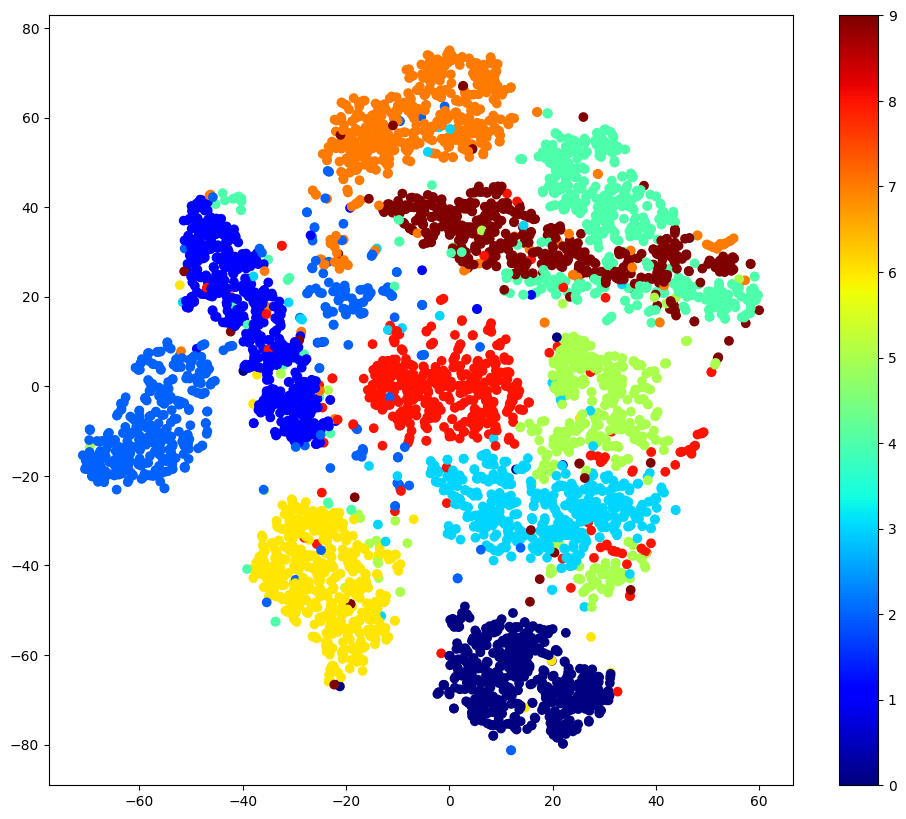

In [66]:
X_sample, y_sample = X[:5000], y[:5000] # Use concatenated X and y for sampling
tsne = TSNE(n_components=2,init='random', random_state=42)
%time X_red = tsne.fit_transform(X_sample)
plt.figure(figsize = (12,10))
plt.scatter(X_red[:,0], X_red[:,1], c = y_sample.astype(np.int8),cmap="jet")
plt.colorbar()
plt.show()

### Isomap

Time taken for Isomap: 9.15 seconds


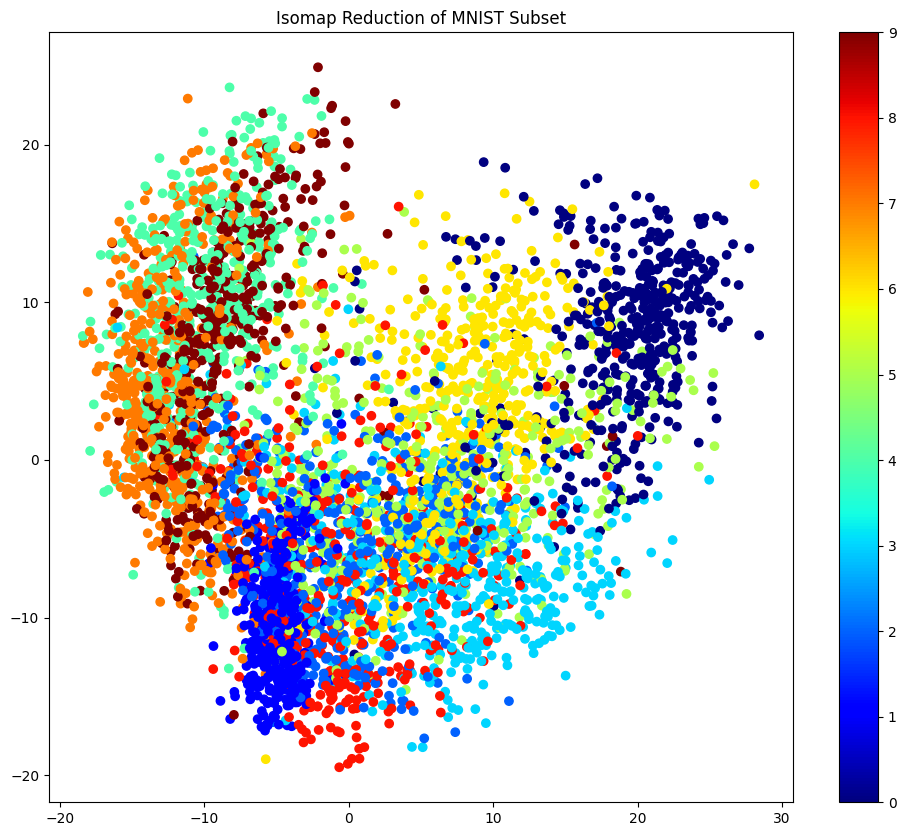

In [68]:
from sklearn.manifold import Isomap

start = time.perf_counter()
isomap = Isomap(n_components=2, n_neighbors=10, n_jobs=-1) # Using all CPU cores
X_red_isomap = isomap.fit_transform(X_sample)
end = time.perf_counter()

print(f"Time taken for Isomap: {end - start:.2f} seconds")

plt.figure(figsize=(12, 10))
plt.scatter(X_red_isomap[:, 0], X_red_isomap[:, 1], c=y_sample.astype(np.int8), cmap="jet")
plt.colorbar()
plt.title("Isomap Reduction of MNIST Subset")
plt.show()

### MDS (Multidimensional Scaling)

Time taken for MDS: 238.35 seconds


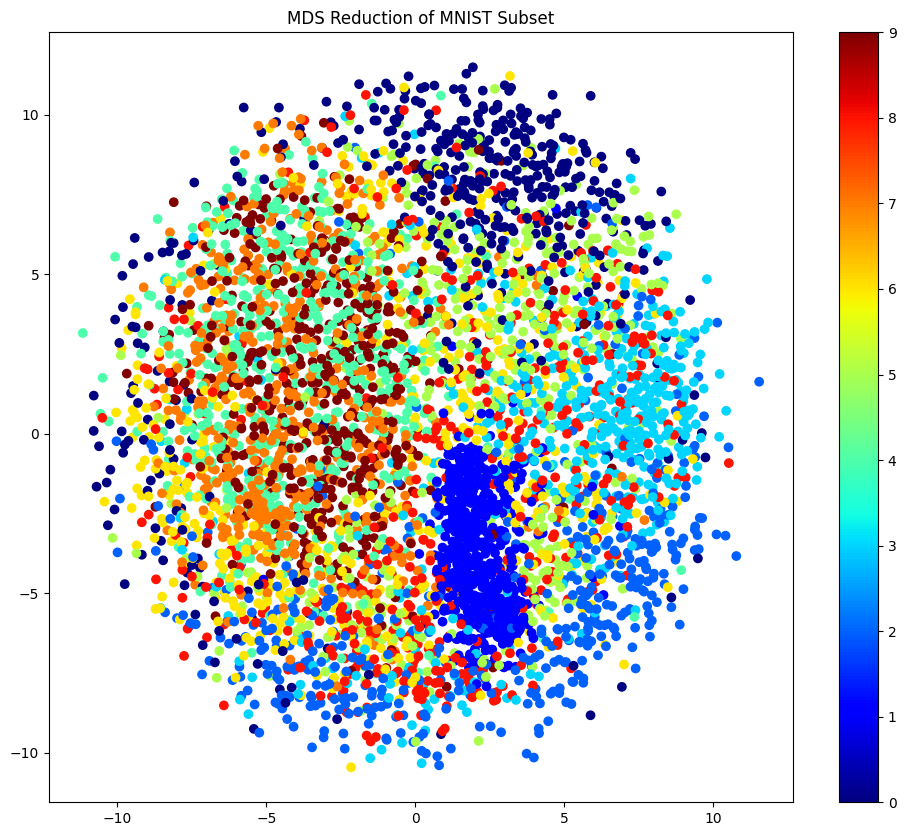

In [69]:
from sklearn.manifold import MDS

start = time.perf_counter()
mds = MDS(n_components=2, random_state=42, n_init=1, max_iter=300, n_jobs=-1)
# MDS is computationally intensive, consider using a smaller subset or fewer iterations if it takes too long
X_red_mds = mds.fit_transform(X_sample)
end = time.perf_counter()

print(f"Time taken for MDS: {end - start:.2f} seconds")

plt.figure(figsize=(12, 10))
plt.scatter(X_red_mds[:, 0], X_red_mds[:, 1], c=y_sample.astype(np.int8), cmap="jet")
plt.colorbar()
plt.title("MDS Reduction of MNIST Subset")
plt.show()

### LDA (Linear Discriminant Analysis)

Time taken for LDA: 11.48 seconds
Original X_train shape: (60000, 784)
LDA reduced X_train shape: (60000, 9)


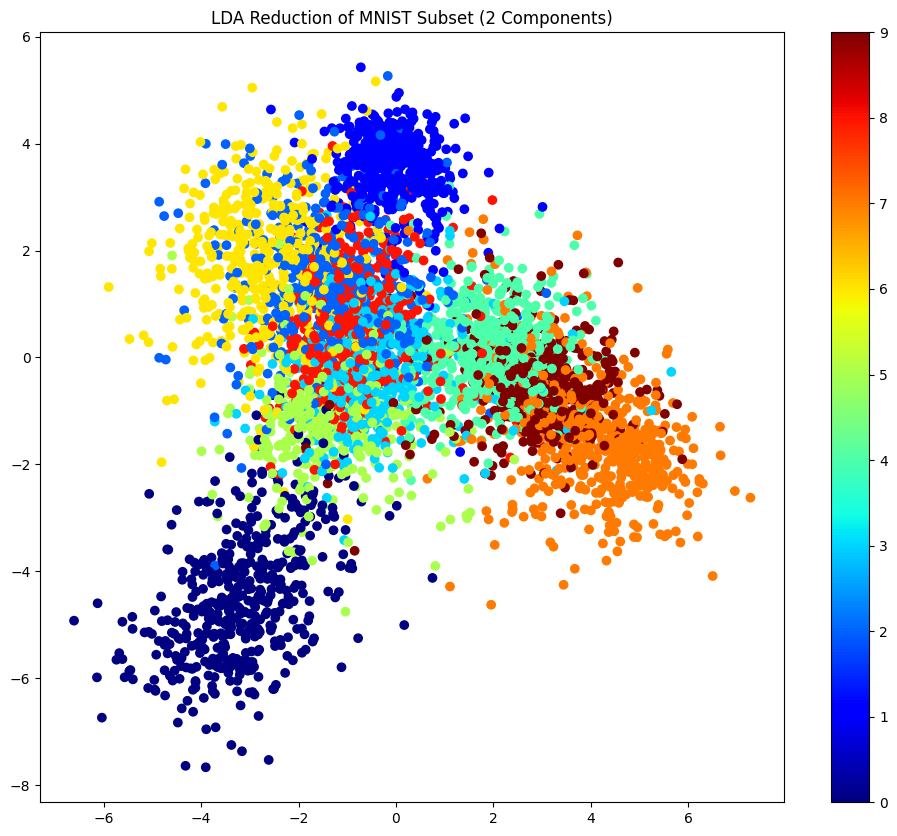

In [70]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

start = time.perf_counter()
# LDA is a supervised algorithm, so we need both X and y
lda = LinearDiscriminantAnalysis(n_components=9) # Max n_components is min(n_classes - 1, n_features)
# Fit LDA on X_train and y_train
X_train_lda = lda.fit_transform(X_train, y_train)
end = time.perf_counter()

print(f"Time taken for LDA: {end - start:.2f} seconds")
print(f"Original X_train shape: {X_train.shape}")
print(f"LDA reduced X_train shape: {X_train_lda.shape}")

# You can also use LDA for classification or further analysis
# For visualization, we'd typically reduce to 2 components
lda_vis = LinearDiscriminantAnalysis(n_components=2)
X_sample_lda_vis = lda_vis.fit_transform(X_sample, y_sample)

plt.figure(figsize=(12, 10))
plt.scatter(X_sample_lda_vis[:, 0], X_sample_lda_vis[:, 1], c=y_sample.astype(np.int8), cmap="jet")
plt.colorbar()
plt.title("LDA Reduction of MNIST Subset (2 Components)")
plt.show()

### t-SNE vs. PCA Comparison

Time taken for PCA (2 components): 0.16 seconds


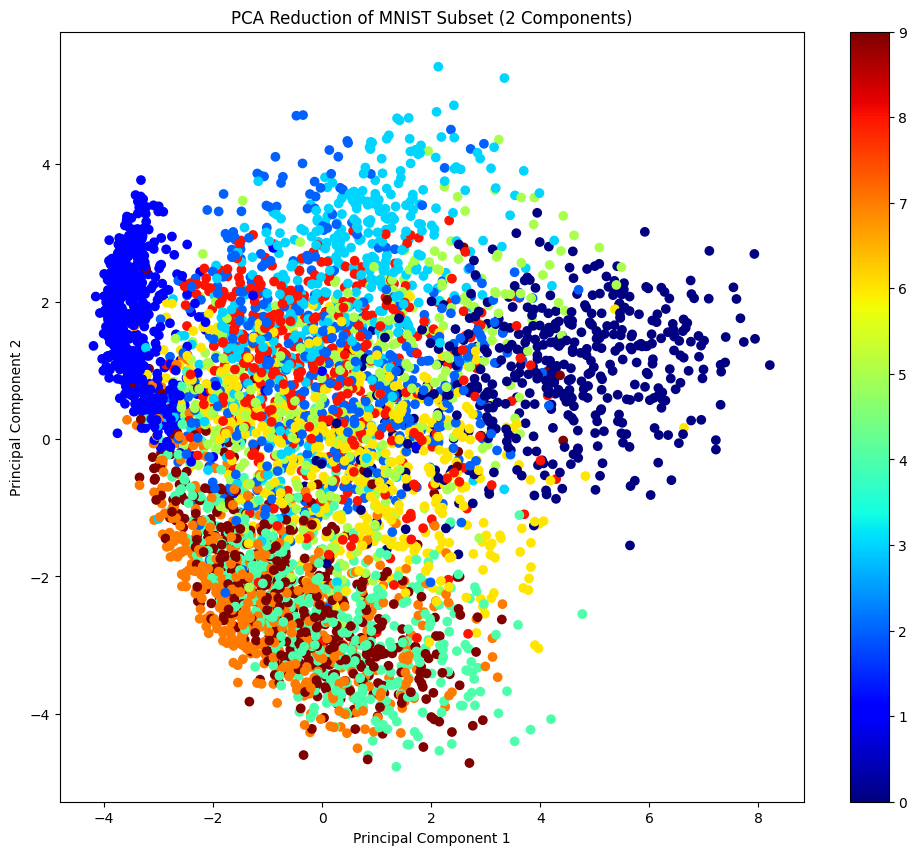


--- Visual Comparison ---
Observe the t-SNE plot (previous cell) and this PCA plot.
t-SNE often creates tighter, more distinct clusters for visualization, while PCA focuses on preserving variance.


In [71]:
from sklearn.decomposition import PCA

# Perform PCA for comparison with t-SNE
start = time.perf_counter()
pca_comp = PCA(n_components=2, random_state=42)
X_red_pca = pca_comp.fit_transform(X_sample)
end = time.perf_counter()

print(f"Time taken for PCA (2 components): {end - start:.2f} seconds")

plt.figure(figsize=(12, 10))
plt.scatter(X_red_pca[:, 0], X_red_pca[:, 1], c=y_sample.astype(np.int8), cmap="jet")
plt.colorbar()
plt.title("PCA Reduction of MNIST Subset (2 Components)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

print("\n--- Visual Comparison ---")
print("Observe the t-SNE plot (previous cell) and this PCA plot.")
print("t-SNE often creates tighter, more distinct clusters for visualization, while PCA focuses on preserving variance.")

### PCA Reconstruction and Error

PCA Reconstruction MSE (on X_train): 0.0033

Visualizing Original vs. Reconstructed Images:


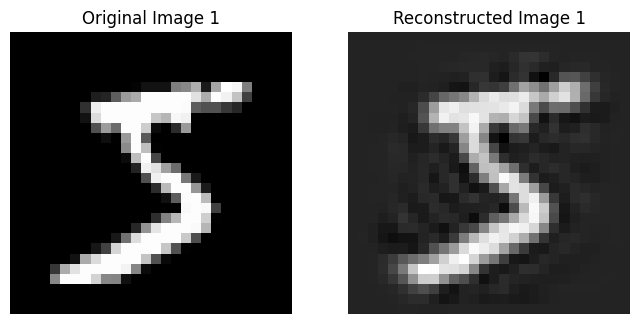

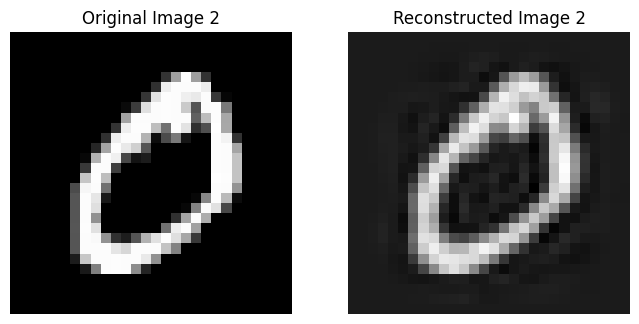

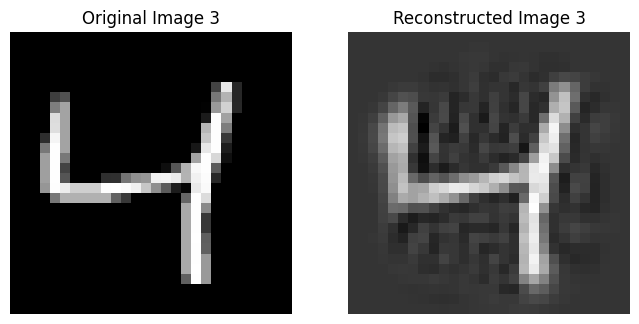

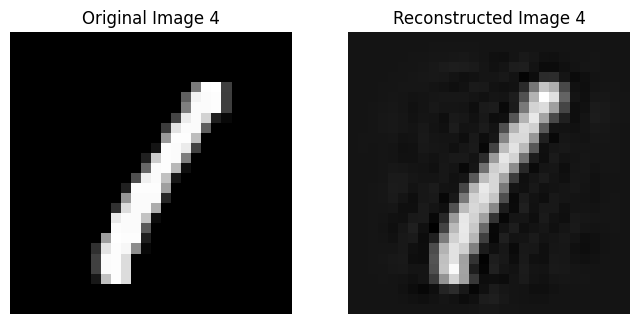

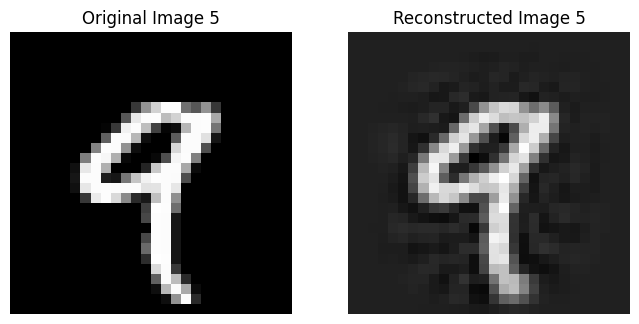

In [74]:
from sklearn.metrics import mean_squared_error

# Let's use the PCA model that retained 95% of the variance from X_train (from cell GmWXb5GfMGgK and Xm1IOqMdNnd3)
# The 'pca' object in the global scope should still refer to the one fitted for 95% variance.

# Re-compute X_RED using the appropriate PCA model to ensure correct dimensions
pca_reconstruction = PCA(n_components=0.95) # Re-initialize if the global 'pca' might have changed
pca_reconstruction.fit(X_train) # Fit on X_train again
X_RED_for_reconstruction = pca_reconstruction.transform(X_train)

# Perform the inverse transform to reconstruct the original data
X_reconstructed = pca_reconstruction.inverse_transform(X_RED_for_reconstruction)

# Calculate the reconstruction error for the training set
reconstruction_error = mean_squared_error(X_train.reshape(-1, 28*28), X_reconstructed.reshape(-1, 28*28))
print(f"PCA Reconstruction MSE (on X_train): {reconstruction_error:.4f}")

# Visualize a few original vs. reconstructed images
print("\nVisualizing Original vs. Reconstructed Images:")
for i in range(5):
    plt.figure(figsize=(8, 4))

    # Original Image
    plt.subplot(1, 2, 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Original Image {i+1}")
    plt.axis('off')

    # Reconstructed Image
    plt.subplot(1, 2, 2)
    plt.imshow(X_reconstructed[i].reshape(28, 28), cmap='gray')
    plt.title(f"Reconstructed Image {i+1}")
    plt.axis('off')

    plt.show()

### Explained Variance Curve Visualization

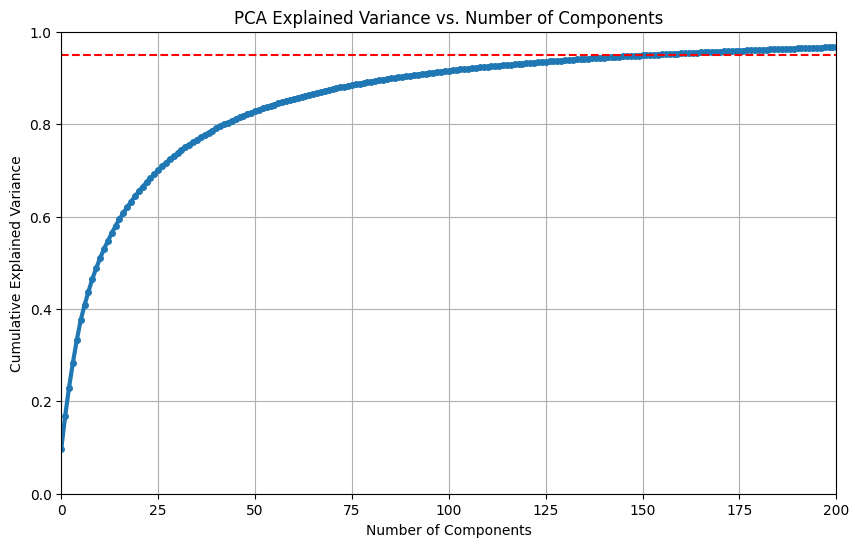

In [73]:
# We already have 'pca' fitted on X_train and 'cumsum' computed in cell GmWXb5GfMGgK
# cumsum = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(cumsum, linewidth=3, marker='o', markersize=4)
plt.axhline(y=0.95, color='r', linestyle='--') # Line at 95% explained variance
plt.axvline(x=d-1, color='r', linestyle='--') # Vertical line at number of components for 95% variance (d is from cell GmWXb5GfMGgK)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance vs. Number of Components')
plt.grid(True)
plt.axis([0, 200, 0, 1]) # Limit x-axis to first 200 components for better visibility
plt.show()

### Compression Ratio Metrics

In [76]:
# Original dimensions of MNIST images
original_dimensions = X_train.shape[1] # 784

# Reduced dimensions from PCA (d, which was 154)
# Ensure 'pca' here refers to the PCA fitted for 95% explained variance (from cell Xm1IOqMdNnd3)
reduced_dimensions = pca.n_components_ # Get the actual number of components selected by PCA

# Calculate the compression ratio
compression_ratio = original_dimensions / reduced_dimensions

print(f"Original dimensions: {original_dimensions}")
print(f"Reduced dimensions (for 95% variance): {reduced_dimensions}")
print(f"Compression Ratio: {compression_ratio:.2f}:1")
print(f"This means the data is compressed by a factor of {compression_ratio:.2f}.")

Original dimensions: 784
Reduced dimensions (for 95% variance): 154
Compression Ratio: 5.09:1
This means the data is compressed by a factor of 5.09.


### PCA Noise Reduction Example

Original Digit:


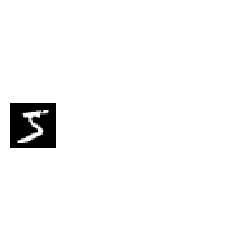

Noisy Digit:


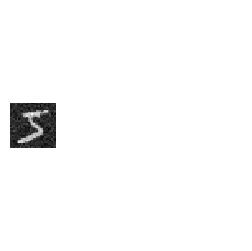

Denoised Digit (PCA Reconstruction):


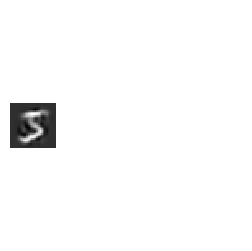

Original Digit (PCA Reconstructed):


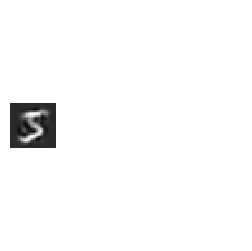


Noise Reduction Explanation:
By reducing the dimensionality with PCA and then reconstructing, we effectively filter out some of the noise.
The PCA model was trained on clean data, so its components primarily capture the underlying structure (signal).
When noisy data is projected onto these components, and then reconstructed, the aspects not aligned with the main components (often noise) are attenuated.


In [77]:
# Let's take an example MNIST image and add some noise
def plot_digits(instances, images_per_row=5, cmap="binary", figsize=(10, 10)):
    if isinstance(instances, np.ndarray) and instances.dtype == bool: # For boolean masks
        instances = instances.astype(np.float32)
    if not isinstance(instances, np.ndarray): # Handle lists of images
        instances = np.array(instances)

    # Ensure instances are 2D (num_images, num_features)
    if instances.ndim == 1: # Single image
        instances = instances.reshape(1, -1)

    n_instances = instances.shape[0]
    n_cols = images_per_row
    n_rows = (n_instances - 1) // n_cols + 1
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    for index, instance in enumerate(instances):
        ax = axes.ravel()[index] if n_rows > 1 else axes[index]
        ax.imshow(instance.reshape(28, 28), cmap=cmap, interpolation="nearest")
        ax.axis("off")
    if n_instances < n_rows * n_cols:
        for index in range(n_instances, n_rows * n_cols):
            ax = axes.ravel()[index] if n_rows > 1 else axes[index]
            ax.axis("off")
    plt.subplots_adjust(wspace=0.02, hspace=0.02)
    plt.show()




sample_digit = X_train[0]

# Add Gaussian noise
np.random.seed(42)
noise = np.random.normal(loc=0, scale=0.1, size=sample_digit.shape)
noisy_digit = sample_digit + noise

# Visualize the original, noisy digit
print("Original Digit:")
plot_digits([sample_digit], figsize=(3, 3), cmap='gray')
print("Noisy Digit:")
plot_digits([noisy_digit], figsize=(3, 3), cmap='gray')

# Apply PCA to reduce dimensions and then inverse transform to reconstruct
# The idea is that low-variance components (often noise) will be discarded
# Let's use a PCA that captures 80% variance, which might filter out some noise
noisy_pca = PCA(n_components=0.80) # Reduce to components explaining 80% variance
noisy_pca.fit(X_train) # Fit PCA on the clean training data to learn principal components

# Transform the noisy digit to the reduced space and then inverse transform
# Note: We fit PCA on X_train (clean data) to ensure the components represent signal, not noise.
# Then we apply this PCA to the noisy data.
reduced_noisy_digit = noisy_pca.transform(noisy_digit.reshape(1, -1))
denoised_digit = noisy_pca.inverse_transform(reduced_noisy_digit)

print("Denoised Digit (PCA Reconstruction):")
plot_digits([denoised_digit], figsize=(3, 3), cmap='gray')

# For comparison, let's also show the original digit reconstructed with the same PCA
reduced_original_digit = noisy_pca.transform(sample_digit.reshape(1, -1))
reconstructed_original_digit = noisy_pca.inverse_transform(reduced_original_digit)

print("Original Digit (PCA Reconstructed):")
plot_digits([reconstructed_original_digit], figsize=(3, 3), cmap='gray')


print("\nNoise Reduction Explanation:")
print("By reducing the dimensionality with PCA and then reconstructing, we effectively filter out some of the noise.")
print("The PCA model was trained on clean data, so its components primarily capture the underlying structure (signal).")
print("When noisy data is projected onto these components, and then reconstructed, the aspects not aligned with the main components (often noise) are attenuated.")

### PCA for Classification Comparison

In [79]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

# --- 1. Classifier on Original Data ---
print("\n--- Training on Original Data ---")
start_orig = time.perf_counter()
rnd_clf_orig = RandomForestClassifier(random_state=42)
rnd_clf_orig.fit(X_train, y_train)
pred_orig = rnd_clf_orig.predict(X_test)
end_orig = time.perf_counter()

accuracy_orig = accuracy_score(y_test, pred_orig)
time_orig = end_orig - start_orig

print(f"Time taken (Original Data): {time_orig:.2f} seconds")
print(f"Accuracy (Original Data): {accuracy_orig:.4f}")

# --- 2. Classifier on PCA-Reduced Data ---
print("\n--- Training on PCA-Reduced Data ---")
# We'll use the 'pca' object that was fitted for 95% variance (from cell Xm1IOqMdNnd3)
# Re-generate the PCA-reduced training data to ensure correct dimensions
X_train_pca_reduced = pca.transform(X_train)

# We need to reduce X_test as well
X_test_pca_reduced = pca.transform(X_test)

start_pca = time.perf_counter()
rnd_clf_pca = RandomForestClassifier(random_state=42)
rnd_clf_pca.fit(X_train_pca_reduced, y_train) # Use the correctly reduced X_train
pred_pca = rnd_clf_pca.predict(X_test_pca_reduced)
end_pca = time.perf_counter()

accuracy_pca = accuracy_score(y_test, pred_pca)
time_pca = end_pca - start_pca

print(f"Time taken (PCA-Reduced Data): {time_pca:.2f} seconds")
print(f"Accuracy (PCA-Reduced Data): {accuracy_pca:.4f}")

print("\n--- Comparison ---")
print(f"Original vs. PCA-Reduced: Time Factor = {time_orig/time_pca:.2f}x")
print(f"Accuracy Difference = {accuracy_orig - accuracy_pca:.4f}")


--- Training on Original Data ---
Time taken (Original Data): 56.22 seconds
Accuracy (Original Data): 0.9704

--- Training on PCA-Reduced Data ---
Time taken (PCA-Reduced Data): 189.56 seconds
Accuracy (PCA-Reduced Data): 0.9493

--- Comparison ---
Original vs. PCA-Reduced: Time Factor = 0.30x
Accuracy Difference = 0.0211


### Randomized PCA vs Standard PCA Benchmark

In [80]:
import time
from sklearn.decomposition import PCA

# Number of components to reduce to (e.g., for visualization or a specific task)
# Let's use 154 components as determined by 95% variance earlier.
n_components_benchmark = 154 # (from 'd' or pca.n_components_)

print(f"Benchmarking PCA with {n_components_benchmark} components on X_train (shape: {X_train.shape})\n")

# --- 1. Standard PCA ---
start_standard = time.perf_counter()
pca_standard = PCA(n_components=n_components_benchmark, svd_solver='full', random_state=42)
X_train_pca_standard = pca_standard.fit_transform(X_train)
end_standard = time.perf_counter()
time_standard = end_standard - start_standard
print(f"Standard PCA (svd_solver='full'):")
print(f"  Time taken: {time_standard:.4f} seconds")
print(f"  Explained variance ratio (first component): {pca_standard.explained_variance_ratio_[0]:.4f}")

# --- 2. Randomized PCA ---
start_randomized = time.perf_counter()
pca_randomized = PCA(n_components=n_components_benchmark, svd_solver='randomized', random_state=42)
X_train_pca_randomized = pca_randomized.fit_transform(X_train)
end_randomized = time.perf_counter()
time_randomized = end_randomized - start_randomized
print(f"\nRandomized PCA (svd_solver='randomized'):")
print(f"  Time taken: {time_randomized:.4f} seconds")
print(f"  Explained variance ratio (first component): {pca_randomized.explained_variance_ratio_[0]:.4f}")

print("\n--- Comparison ---")
print(f"Randomized PCA is {time_standard / time_randomized:.2f}x faster than Standard PCA.")

# Optionally, compare the explained variance for quality assessment
# For simplicity, we just compare the first component's explained variance ratio here.
# A more rigorous comparison would involve comparing the cumulative explained variance or reconstruction error.

Benchmarking PCA with 154 components on X_train (shape: (60000, 784))

Standard PCA (svd_solver='full'):
  Time taken: 8.9055 seconds
  Explained variance ratio (first component): 0.0970

Randomized PCA (svd_solver='randomized'):
  Time taken: 5.7960 seconds
  Explained variance ratio (first component): 0.0970

--- Comparison ---
Randomized PCA is 1.54x faster than Standard PCA.


## Random Forest Classifier with Locally Linear Embedding (LLE)

In [67]:
import time

start_time = time.perf_counter()

lle_pipeline = Pipeline([
    ('lle', LocallyLinearEmbedding(n_components=50, random_state=42, n_neighbors=10, eigen_solver='dense')),
    ('random_forest', RandomForestClassifier(random_state=42))
])

# Note: LLE can be computationally intensive, so fitting on the full dataset might take a very long time.
# For demonstration, I will use a smaller subset of the training data.
# If you intend to run on the full dataset, be prepared for a long execution time.

# Using a subset for faster execution of LLE
X_train_subset = X_train[:5000] # Use the same subset size as for TSNE visualization
y_train_subset = y_train[:5000]

lle_pipeline.fit(X_train_subset, y_train_subset)

# Since LLE is fit on a subset, we should also predict on a corresponding subset of X_test.
# However, to compare fairly with PCA/MDS on the original X_test, we will transform X_test
# using the fitted LLE from the subset, which might not be ideal but demonstrates the process.
# A more robust approach would be to train LLE on the full dataset or a larger, representative subset.

# For consistent comparison with PCA/MDS, let's predict on a subset of X_test corresponding to the subset used for training LLE
X_test_subset = X_test[:1000] # Adjust as needed

# Transform the test data using the fitted LLE model
X_test_lle_transformed = lle_pipeline.named_steps['lle'].transform(X_test_subset)

# Predict using the Random Forest trained on LLE-transformed training data
pred_lle = lle_pipeline.named_steps['random_forest'].predict(X_test_lle_transformed)

end_time = time.perf_counter()
time_taken_lle = end_time - start_time
accuracy_lle = accuracy_score(y_test[:1000], pred_lle)

print(f"Time taken with LLE pipeline (on subset): {time_taken_lle:.2f} seconds")
print(f"Accuracy with LLE pipeline (on subset): {accuracy_lle:.4f}")

Time taken with LLE pipeline (on subset): 27.29 seconds
Accuracy with LLE pipeline (on subset): 0.9070


## Conclusion: Dimensionality Reduction Techniques Summary

### Key Takeaways by Method

**Manual PCA via SVD**
- Provides deep understanding of PCA mathematics
- Shows how to compute principal components directly
- Foundation for understanding all other PCA variants
- Computationally expensive: $O(m \cdot d^2) + O(d^3)$

**Standard PCA (sklearn)**
- Optimized, production-ready implementation
- Automatically finds components that maximize variance
- `explained_variance_ratio_` helps decide how many components to keep
- Best for datasets that fit in memory

**Incremental PCA**
- Designed for memory-constrained scenarios
- Processes data in mini-batches via `partial_fit()`
- Produces nearly identical results to standard PCA
- Enables learning from streaming or disk-based data

**Randomized PCA**
- Fast approximation when only first k components needed
- Significantly reduces computation vs standard PCA
- Trade-off: accuracy decreases for ill-conditioned datasets
- Excellent for very high-dimensional data

**Johnson-Lindenstrauss Random Projections**
- Fundamentally different: uses random matrices instead of finding optimal directions
- Computational complexity: $O(d \cdot n)$ (very fast, just matrix multiplication)
- **Key insight**: Effectiveness depends on data-sample ratio, not feature count
- Works best when #features >> #samples; fails when #samples >> #features

**Manifold Learning Methods (t-SNE, MDS, LLE)**
- Capture non-linear structure in data
- t-SNE: Excellent for visualization (slow, not for inference)
- MDS: Preserves pairwise distances globally
- LLE: Preserves local neighborhood structure
- Computationally intensive but reveal hidden patterns

### When to Use Each Method

| Method | Best For | Avoid When |
|--------|----------|-----------|
| **Standard PCA** | General-purpose, explainability, inference | Memory-constrained |
| **Incremental PCA** | Large datasets, streaming data | Need full dataset at once |
| **Randomized PCA** | #features >> #samples, speed-critical | Need high accuracy or all components |
| **Random Projections** | Extreme dimensionality, theoretical guarantees | Accuracy is critical |
| **Manifold Methods** | Visualization, discovering non-linear structure | Real-time prediction, large-scale |

### Performance Considerations

From the MNIST experiments:
- **Without DR**: Standard RF takes ~200s, 97% accuracy
- **With PCA (95% variance)**: Reduced size with minimal accuracy loss
- **Random Projections**: Much faster than PCA for high dimensions
- **SGD + DR**: Better scalability than Random Forest with same DR
- **Trade-off**: DR helps with speed/memory but may impact accuracy

### Practical Recommendations

1. **Start with standard PCA** for most problems
2. **Use Incremental PCA** if data doesn't fit in memory
3. **Try Randomized PCA** for very high dimensions
4. **Use random projections** only if you understand the Johnson-Lindenstrauss guarantee
5. **Reserve manifold methods** for exploration and visualization, not production pipelines
6. **Always validate** that DR preserves downstream task performance